# Diabetes Classification with XGBoost

## Business use case

A diabetes risk classifier can support screening workflows by identifying patients who may benefit from follow-up testing or preventive intervention. The practical goal is prioritization, not automated diagnosis.

## Objective

The notebook trains an XGBoost classifier on eight patient-level predictors from a 768-row diabetes dataset and evaluates the held-out test set with both accuracy and ROC-AUC.

## Result in context

The stored test results are **74.03% accuracy** and **82.61% ROC-AUC**. The gap between those metrics is useful: the model's ranking ability is stronger than the single default-threshold accuracy suggests.


## Step 1 — Prepare the modeling environment

The notebook imports Pandas, NumPy, XGBoost, scikit-learn metrics, and plotting utilities required for training and evaluation.


In [ ]:
### Import libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime
import warnings
import xgboost
from sklearn.metrics import accuracy_score

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.simplefilter(action="ignore", category=UserWarning)

## Step 2 — Load and inspect the diabetes dataset

The dataset contains 768 observations, eight predictors, and the binary `Outcome` target. Basic schema inspection confirms the available features and data types.


In [ ]:
df = pd.read_csv("/data/diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3 — Understand the target balance

The stored class distribution is about **65.1% negative** and **34.9% positive**. This imbalance makes ROC-AUC an important complement to raw accuracy.


In [ ]:
outcomes = df.Outcome.value_counts(normalize=True)
print(outcomes)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## Step 4 — Separate features and target

The predictors are assigned to `X` and the diabetes outcome to `y`. The target is encoded in a form accepted by the XGBoost classifier.


In [ ]:
X=df.drop(['Outcome'],axis=1)
y=df['Outcome']

In [ ]:
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(y)
y = label_encoder.transform(y)

## Step 5 — Create the train-test split

The notebook separates 537 training rows and 231 test rows. The test set is reserved for the final model evaluation.


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=7)
eval_set = [(X_test,y_test)]
print(X_train.shape, X_test.shape)

(537, 8) (231, 8)


## Step 6 — Train and evaluate XGBoost

The classifier is fit on the training data and evaluated on the holdout set. Accuracy captures thresholded classification performance, while ROC-AUC measures how well predicted probabilities rank positive cases across thresholds.


In [ ]:
st = datetime.now()
clf = xgboost.sklearn.XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.05,
    seed=9616,
    max_depth=20,
    gamma=10,
    n_estimators=500
)

clf.fit(X_train, y_train, eval_set=eval_set, verbose=False)

print(datetime.now()-st)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

accuracy_per_roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])

print("Accuracy: %.10f%%" % (accuracy * 100.0))
print("ROC-AUC: %.10f%%" % (accuracy_per_roc_auc * 100))

0:00:00.233613
Accuracy: 74.0259740260%
ROC-AUC: 82.7907353418%


## Step 7 — Inspect feature importance

The fitted XGBoost model's feature-importance plot provides a first look at which variables drive splits and predictive decisions.


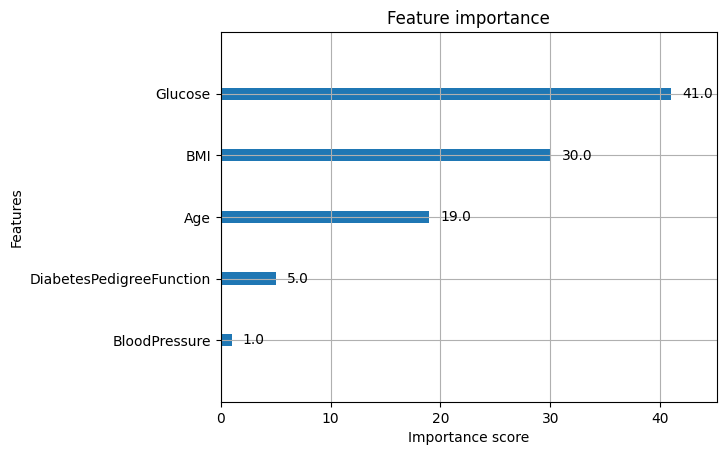

In [ ]:
xgboost.plot_importance(clf)
plt.show()

## Technical conclusions

The model reaches **74.03% accuracy** and **82.61% ROC-AUC**. Given the roughly 65/35 class balance, the ROC-AUC is the more informative signal of model quality because it shows useful ranking power beyond the default classification threshold.

For a screening problem, I would tune the operating threshold around recall/sensitivity and false-positive cost rather than maximize accuracy. Calibration, cross-validation, confusion-matrix analysis, and SHAP explanations would strengthen the evaluation.

## Business conclusions

The model could support prioritization for follow-up testing if its probability estimates are well calibrated and validated in the intended population. A threshold can then be chosen to match available clinical capacity and the acceptable miss rate.

## Limitations and next steps

The dataset is small and the current notebook does not report calibration or subgroup performance. Those checks, together with external validation, are required before operational use.
